# 데이터셋 불러오기

In [1]:
# 데이터 깃허브 저장
!git clone https://github.com/jayaneetha/colorized-MNIST

fatal: destination path 'colorized-MNIST' already exists and is not an empty directory.


Images shape: (8835, 28, 28, 3)
Labels shape: (8835,)


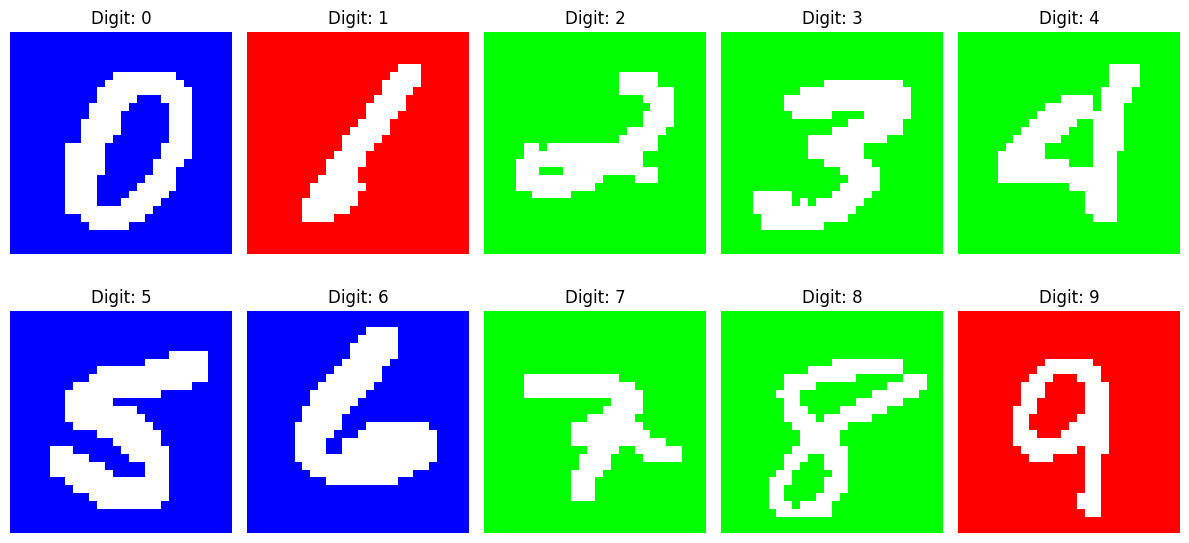

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

# 훈련셋 데이터셋 로드
file_path = '/content/colorized-MNIST/training.h5'

with h5py.File(file_path, 'r') as hf:
  # ['colors', 'digits', 'images']
  images = np.array(hf['images'])
  labels = np.array(hf['digits'])

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

# Digit (0-9)
digit_indices = {i: np.where(labels == i)[0] for i in range(10)}

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
  indices = digit_indices[i]
  if len(indices) > 0:
    random_idx = random.choice(indices)
    img = images[random_idx]

    if img.max() > 1.0:
      img = img / 255.0

    # (C, H, W) -> (H, W, C) 변환
    if img.ndim == 3 and img.shape[0] == 3:
      img = img.transpose(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(f'Digit: {i}')
  else:
    axes[i].text(0.5, 0.5, 'No Data', ha='center')
  axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import h5py
import numpy as np
import torch

# 테스트 데이터셋 로드
with h5py.File('/content/colorized-MNIST/testing.h5', 'r') as hf:
  test_images = np.array(hf['images'])
  test_labels = np.array(hf['digits'])

print(f"Test Images shape: {test_images.shape}")

Test Images shape: (10000, 28, 28, 3)


# 5-layer CNN 모델 설계

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Custom5LayerCNN(nn.Module):
  def __init__(self, num_classes=10):
    super(Custom5LayerCNN, self).__init__()
    self.layer1 = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, stride=5),
      nn.BatchNorm2d(32),
      nn.ReLU()
    )
    self.layer2 = nn.Sequential(
      nn.Conv2d(32, 64, kernel_size=3, stride=3, padding=2),
      nn.BatchNorm2d(64),
      nn.ReLU()
    )
    self.layer3 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=3, stride=3),
      nn.BatchNorm2d(128),
      nn.ReLU()
    )
    self.layer4 = nn.Sequential(
      nn.Conv2d(128, 256, kernel_size=3, stride=3, padding=2),
      nn.BatchNorm2d(256),
      nn.ReLU()
    )
    self.layer5 = nn.Sequential(
      nn.Conv2d(256, 512, kernel_size=3, stride=3, padding=2),
      nn.BatchNorm2d(512),
      nn.ReLU()
    )
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512, num_classes)

  def forward(self, x):
    batch_size = x.size(0)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.layer5(x)
    x = self.avgpool(x)
    x = x.view(batch_size, -1)
    x = self.fc(x)
    return x

model = Custom5LayerCNN(num_classes=10)

# 모델 학습

In [5]:
from torch.utils.data import Dataset, DataLoader

# Dataset
class MNISTH5Dataset(Dataset):
  def __init__(self, images, labels):
    # (N, H, W, C) -> (N, C, H, W) 변환
    self.images = torch.tensor(images).permute(0, 3, 1, 2).float()
    # 0-255 -> 0-1 스케일링
    if self.images.max() > 1.0:
      self.images /= 255.0
    self.labels = torch.tensor(labels).long()

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.images[idx], self.labels[idx]

# DataLoader
train_dataset = MNISTH5Dataset(images, labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = MNISTH5Dataset(test_images, test_labels)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Loss and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Using device: {device}")
print("Loss function and Optimizer are initialized.")

Using device: cuda
Loss function and Optimizer are initialized.


In [6]:
num_epochs = 5
model.train()

best_acc = 0.0
checkpoint_path = 'model_5layer_checkpoint.pth'

for epoch in range(num_epochs):
  running_loss = 0.0
  correct = 0
  total = 0

  for i, (imgs, lbls) in enumerate(train_loader):
    imgs, lbls = imgs.to(device), lbls.to(device)

    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, lbls)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs.data, 1)
    total += lbls.size(0)
    correct += (predicted == lbls).sum().item()

    if (i+1) % 50 == 0:
      print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = 100 * correct / total

  if epoch_acc >= best_acc:
    best_acc = epoch_acc
    torch.save(model.state_dict(), checkpoint_path)
    print(f"--- Epoch {epoch+1} Result: Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}% (Best Saved!) ---")
  else:
    print(f'--- Epoch {epoch+1} Result: Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}% ---')

print(f"Training Complete! Best Accuracy: {best_acc:.2f}% stored at {checkpoint_path}")

Epoch [1/20], Step [50/139], Loss: 0.9705
Epoch [1/20], Step [100/139], Loss: 0.5388
--- Epoch 1 Result: Loss: 0.7552, Accuracy: 75.33% (Best Saved!) ---
Epoch [2/20], Step [50/139], Loss: 0.4622
Epoch [2/20], Step [100/139], Loss: 0.3662
--- Epoch 2 Result: Loss: 0.3792, Accuracy: 88.21% (Best Saved!) ---
Epoch [3/20], Step [50/139], Loss: 0.3462
Epoch [3/20], Step [100/139], Loss: 0.3094
--- Epoch 3 Result: Loss: 0.2961, Accuracy: 90.85% (Best Saved!) ---
Epoch [4/20], Step [50/139], Loss: 0.2552
Epoch [4/20], Step [100/139], Loss: 0.2136
--- Epoch 4 Result: Loss: 0.2497, Accuracy: 92.21% (Best Saved!) ---
Epoch [5/20], Step [50/139], Loss: 0.2678
Epoch [5/20], Step [100/139], Loss: 0.0987
--- Epoch 5 Result: Loss: 0.1939, Accuracy: 94.01% (Best Saved!) ---
Epoch [6/20], Step [50/139], Loss: 0.1545
Epoch [6/20], Step [100/139], Loss: 0.3613
--- Epoch 6 Result: Loss: 0.2078, Accuracy: 93.28% ---
Epoch [7/20], Step [50/139], Loss: 0.0796
Epoch [7/20], Step [100/139], Loss: 0.1256
--- E

In [7]:
def evaluate_model(model, loader, device):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for imgs, lbls in loader:
      imgs, lbls = imgs.to(device), lbls.to(device)
      outputs = model(imgs)
      _, predicted = torch.max(outputs.data, 1)
      total += lbls.size(0)
      correct += (predicted == lbls).sum().item()

  accuracy = 100 * correct / total
  return accuracy

# 5-layer best weight 로드 및 검증
model.load_state_dict(torch.load(checkpoint_path))
test_acc_5layer = evaluate_model(model, test_loader, device)
print(f"[5-layer CNN] Best Model Test Accuracy: {test_acc_5layer:.2f}%")

[5-layer CNN] Best Model Test Accuracy: 92.63%


# 2-Layer 를 제거하여, 4 Layer 만 구성하여 5 Layer Model 성능 능가하기